In [ ]:
!pip install openimages

In [1]:
import os
from google.colab import drive

In [ ]:
from openimages.download import download_dataset

In [2]:
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.io import read_image
from torchvision import datasets
import torchvision
import torch
import matplotlib.pyplot as plt
from torchvision.transforms import transforms
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from skimage import io
from skimage.transform import resize
import glob
from PIL import Image

In [3]:
classes = ["Banana", "Orange", "Strawberry"]

In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


Nuotraukų parsisiuntimas

In [ ]:
save_path = "/content/drive/MyDrive/openImages"
os.makedirs(save_path, exist_ok=True)

number_for_samples = 500
download_dataset(save_path, classes, limit=number_for_samples)

100%|██████████| 500/500 [00:10<00:00, 45.53it/s]


{'banana': {'images_dir': '/content/drive/MyDrive/openImages/banana/images'},
 'orange': {'images_dir': '/content/drive/MyDrive/openImages/orange/images'},
 'strawberry': {'images_dir': '/content/drive/MyDrive/openImages/strawberry/images'}}

In [ ]:
os.listdir('/content/drive/MyDrive/openImages')

In [ ]:
base_path = '/content/drive/MyDrive/openImages'
categories = ['banana', 'strawberry', 'orange']

for category in categories:
    folder_path = os.path.join(base_path, category)
    if os.path.exists(folder_path):
        file_count = len([
            f for f in os.listdir(folder_path)
            if os.path.isfile(os.path.join(folder_path, f))
        ])
        print(f"{category}: {file_count} files")
    else:
        print(f"{category}: folder not found")

banana: 500 files
strawberry: 500 files
orange: 500 files


Splittinimas į test ir train

In [ ]:
import os
import random
import shutil

def split_dataset(base_path, categories, train_ratio=0.8):
    train_path = os.path.join(base_path, 'train')
    test_path = os.path.join(base_path, 'test')

    for category in categories:
        os.makedirs(os.path.join(train_path, category), exist_ok=True)
        os.makedirs(os.path.join(test_path, category), exist_ok=True)

    for category in categories:
        source_folder = os.path.join(base_path, category)
        files = [
            f for f in os.listdir(source_folder)
            if os.path.isfile(os.path.join(source_folder, f))
        ]
        random.shuffle(files)

        split_index = int(len(files) * train_ratio)
        train_files = files[:split_index]
        test_files = files[split_index:]

        # Move files to train
        for f in train_files:
            src = os.path.join(source_folder, f)
            dst = os.path.join(train_path, category, f)
            shutil.copy2(src, dst)

        # Move files to test
        for f in test_files:
            src = os.path.join(source_folder, f)
            dst = os.path.join(test_path, category, f)
            shutil.copy2(src, dst)

        print(f"{category}: {len(train_files)} train, {len(test_files)} test")

base_path = '/content/drive/MyDrive/openImages'
categories = ['banana', 'strawberry', 'orange']
split_dataset(base_path, categories)

In [ ]:
import os

def count_split_files(base_path, categories):
    for split in ['train', 'test']:
        print(f"\n--- {split.upper()} ---")
        for category in categories:
            folder_path = os.path.join(base_path, split, category)
            if os.path.exists(folder_path):
                file_count = len([
                    f for f in os.listdir(folder_path)
                    if os.path.isfile(os.path.join(folder_path, f))
                ])
                print(f"{category}: {file_count} files")
            else:
                print(f"{category}: folder not found in {split}/")

base_path = '/content/drive/MyDrive/openImages'
categories = ['banana', 'strawberry', 'orange']
count_split_files(base_path, categories)

Transformacijos

In [5]:
transforms_test = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

transforms_train = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomGrayscale(),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

In [6]:
folder_test = '/content/drive/MyDrive/openImages/test'
folder_train = '/content/drive/MyDrive/openImages/train'

In [7]:
train_data = datasets.ImageFolder(folder_train, transform=transforms_train)
test_data = datasets.ImageFolder(folder_test, transform=transforms_test)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Modelis

In [8]:
class CNN(nn.Module):
    def __init__(self, classes_count):
        super(CNN, self).__init__()

        # Convolutional layers with BatchNorm
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)  # 2x2 pooling reduces size by half

        # Fully Connected Layers
        self.fc1 = nn.Linear(128 * 16 * 16, 256)  # Adjusted for 128x128 images
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, classes_count)

        self.dropout = nn.Dropout(0.5)  # Dropout for regularization

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = x.view(-1, 128 * 16 * 16)  # Flatten for FC layers

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

num_classes = 3
net = CNN(num_classes)
print(net)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=32768, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=3, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [9]:
model_path = "/content/drive/MyDrive/models/trained_model.pth"

checkpoint = torch.load(model_path)
net.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [10]:
def set_to_device(data, device):
    return (d.to(device) for d in data)

Train, test

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import classification_report
import numpy as np

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_epoch(model, train_loader, criterion, optimizer, scaler, accumulation_steps=4):
    model.train()
    total_loss = 0.0
    correct_preds = 0
    total_samples = len(train_loader.dataset)

    optimizer.zero_grad()

    for i, (images, labels) in enumerate(train_loader):
        images, labels = set_to_device((images, labels), DEVICE)

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels.long()) / accumulation_steps

        scaler.scale(loss).backward()

        if (i + 1) % accumulation_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += loss.item() * images.size(0)
        correct_preds += (outputs.argmax(1) == labels).sum().item()

    if (i + 1) % accumulation_steps != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

    avg_loss = total_loss / total_samples
    avg_acc = correct_preds / total_samples
    return avg_loss, avg_acc


def test_epoch(model, test_loader, criterion):
    model.eval()
    total_loss = 0.0
    correct_preds = 0
    total_samples = len(test_loader.dataset)

    true_values = []
    predicted_values = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = set_to_device((images, labels), DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels.long())

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(1)
            correct_preds += (preds == labels).sum().item()

            true_values.extend(labels.cpu().numpy())
            predicted_values.extend(preds.cpu().numpy())

    avg_loss = total_loss / total_samples
    avg_acc = correct_preds / total_samples

    return avg_loss, avg_acc, true_values, predicted_values


def train(model, train_loader, test_loader, n_epochs=25, lr=0.0005):
    model.to(DEVICE)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scaler = GradScaler()

    for epoch in range(n_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, scaler)
        test_loss, test_acc, true_vals, pred_vals = test_epoch(model, test_loader, criterion)

        print(f"Epoch {epoch+1}/{n_epochs} | "
              f"Train Loss: {train_loss:.6f} | Train Acc: {train_acc:.3f} | "
              f"Test Loss: {test_loss:.6f} | Test Acc: {test_acc:.3f}")

    torch.save({'model_state_dict': net.state_dict()}, model_path)
    print("Training complete! Model saved.")


In [12]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

In [13]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Confusion matrix

In [14]:
def printConfusionMatrix(conf_matrix, classes):
  plt.figure(figsize=(8, 6))
  sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="magma", cbar=False, xticklabels=classes, yticklabels=classes)
  plt.xlabel("Predicted Labels")
  plt.ylabel("True Labels")
  plt.title("Confusion Matrix")
  plt.show()

In [ ]:
train(net, train_loader, test_loader, n_epochs=64, lr=0.0005)

Epoch 1/64 | Train Loss: 0.176859 | Train Acc: 0.700 | Test Loss: 0.633999 | Test Acc: 0.753
Epoch 2/64 | Train Loss: 0.181780 | Train Acc: 0.673 | Test Loss: 0.586767 | Test Acc: 0.777
Epoch 3/64 | Train Loss: 0.167343 | Train Acc: 0.699 | Test Loss: 0.584329 | Test Acc: 0.770
Epoch 4/64 | Train Loss: 0.170166 | Train Acc: 0.709 | Test Loss: 0.579734 | Test Acc: 0.763
Epoch 5/64 | Train Loss: 0.167506 | Train Acc: 0.699 | Test Loss: 0.568195 | Test Acc: 0.760
Epoch 6/64 | Train Loss: 0.160610 | Train Acc: 0.708 | Test Loss: 0.579286 | Test Acc: 0.773
Epoch 7/64 | Train Loss: 0.156077 | Train Acc: 0.717 | Test Loss: 0.555592 | Test Acc: 0.793
Epoch 8/64 | Train Loss: 0.157600 | Train Acc: 0.727 | Test Loss: 0.561170 | Test Acc: 0.787
Epoch 9/64 | Train Loss: 0.150848 | Train Acc: 0.739 | Test Loss: 0.557844 | Test Acc: 0.790
Epoch 10/64 | Train Loss: 0.149833 | Train Acc: 0.730 | Test Loss: 0.540352 | Test Acc: 0.787
Epoch 11/64 | Train Loss: 0.147466 | Train Acc: 0.738 | Test Loss: 0.

In [ ]:
train(net, train_loader, test_loader, n_epochs=10, lr=0.0005)

Epoch 1/10 | Train Loss: 0.087711 | Train Acc: 0.859 | Test Loss: 0.811211 | Test Acc: 0.717
Epoch 2/10 | Train Loss: 0.090460 | Train Acc: 0.854 | Test Loss: 0.726955 | Test Acc: 0.760
Epoch 3/10 | Train Loss: 0.082899 | Train Acc: 0.869 | Test Loss: 0.692634 | Test Acc: 0.793
Epoch 4/10 | Train Loss: 0.075550 | Train Acc: 0.868 | Test Loss: 0.647141 | Test Acc: 0.787
Epoch 5/10 | Train Loss: 0.069055 | Train Acc: 0.868 | Test Loss: 0.673385 | Test Acc: 0.780
Epoch 6/10 | Train Loss: 0.081084 | Train Acc: 0.863 | Test Loss: 0.736553 | Test Acc: 0.790
Epoch 7/10 | Train Loss: 0.071592 | Train Acc: 0.872 | Test Loss: 0.728903 | Test Acc: 0.783
Epoch 8/10 | Train Loss: 0.071711 | Train Acc: 0.897 | Test Loss: 0.633396 | Test Acc: 0.803
Epoch 9/10 | Train Loss: 0.072893 | Train Acc: 0.873 | Test Loss: 0.714366 | Test Acc: 0.797
Epoch 10/10 | Train Loss: 0.065694 | Train Acc: 0.887 | Test Loss: 0.783000 | Test Acc: 0.783
Training complete! Model saved.


In [15]:
train(net, train_loader, test_loader, n_epochs=5, lr=0.0005)

<ipython-input-11-b027f3dd930b>:79: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
<ipython-input-11-b027f3dd930b>:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/5 | Train Loss: 0.085838 | Train Acc: 0.852 | Test Loss: 0.992056 | Test Acc: 0.727
Epoch 2/5 | Train Loss: 0.074438 | Train Acc: 0.871 | Test Loss: 0.762332 | Test Acc: 0.810
Epoch 3/5 | Train Loss: 0.080483 | Train Acc: 0.868 | Test Loss: 0.676316 | Test Acc: 0.793
Epoch 4/5 | Train Loss: 0.072169 | Train Acc: 0.877 | Test Loss: 0.735773 | Test Acc: 0.773
Epoch 5/5 | Train Loss: 0.072727 | Train Acc: 0.881 | Test Loss: 0.671096 | Test Acc: 0.767
Training complete! Model saved.


Metrikos

In [16]:
true_values = []
predicted_values = []

with torch.no_grad():
    for data in test_loader:
        images, labels = set_to_device(data, DEVICE)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        true_values.extend(labels.cpu().numpy())
        predicted_values.extend(predicted.cpu().numpy())

accuracy = accuracy_score(true_values, predicted_values)
print(f"Accuracy: {accuracy:.5f}")

recall = recall_score(true_values, predicted_values, average='weighted')
print(f"Recall: {recall:.5f}")

precision = precision_score(true_values, predicted_values, average='weighted')
print(f"Precision: {precision:.5f}")

f1 = f1_score(true_values, predicted_values, average='weighted')
print(f"F1 Score: {f1:.5f}")

Accuracy: 0.76667
Recall: 0.76667
Precision: 0.77113
F1 Score: 0.76801


In [17]:
from sklearn.metrics import classification_report
print(classification_report(true_values, predicted_values))

              precision    recall  f1-score   support

           0       0.75      0.71      0.73       100
           1       0.68      0.75      0.71       100
           2       0.88      0.84      0.86       100

    accuracy                           0.77       300
   macro avg       0.77      0.77      0.77       300
weighted avg       0.77      0.77      0.77       300



In [18]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(true_values, predicted_values)
print(cm)

[[71 27  2]
 [16 75  9]
 [ 8  8 84]]


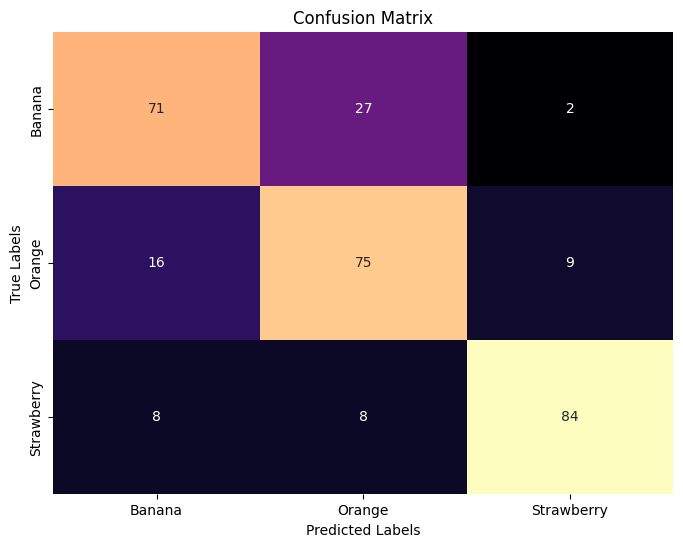

In [19]:
conf_matrix = confusion_matrix(true_values, predicted_values)
printConfusionMatrix(conf_matrix, classes)

Vartotojo sąsają ir modelio iškvietimas per REST API.

In [ ]:
from flask import Flask, render_template, request, jsonify
import torch
from PIL import Image
import logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

app = Flask(__name__, template_folder="/content/drive/MyDrive")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Using device: {device}")

app.config['MAX_CONTENT_LENGTH'] = 5 * 1024 * 1024
app.config['ALLOWED_EXTENSIONS'] = {'png', 'jpg', 'jpeg'}

def allowed_file(filename):
    return '.' in filename and filename.rsplit('.', 1)[1].lower() in app.config['ALLOWED_EXTENSIONS']

@app.route("/")
def home():
    return render_template("index.html")

@app.route('/calculate_scores', methods=['POST'])
def calculate_scores():
    try:
        if 'image' not in request.files:
            return jsonify({"error": "No image uploaded"}), 400

        image_file = request.files['image']

        if image_file.filename == '' or not allowed_file(image_file.filename):
            return jsonify({"error": "Invalid file"}), 400

        image = Image.open(image_file.stream)

        input_tensor = transforms_test(image).unsqueeze(0)
        input_tensor = input_tensor.to(device)

        with torch.no_grad():
            scores = net(input_tensor)
            _, predicted_class = scores.max(1)
            predicted_label = classes[predicted_class]

        return jsonify({
            "success": True,
            "predicted_class": predicted_label
        })

    except Exception as e:
        logger.error(f"Error: {str(e)}")
        return jsonify({"error": "Processing error"}), 500

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000)

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [14/Apr/2025 09:19:02] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [14/Apr/2025 09:19:03] "GET /api/placeholder/400/300 HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [14/Apr/2025 09:19:03] "GET /favicon.ico HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [14/Apr/2025 09:45:54] "POST /calculate_scores HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [14/Apr/2025 09:46:00] "POST /calculate_scores HTTP/1.1" 200 -


In [21]:
from google.colab.output import eval_js
print(eval_js("google.colab.kernel.proxyPort(5000)"))

https://5000-gpu-t4-s-gbez8mz90obl-b.us-west1-0.prod.colab.dev
